# Evaluation with Metrics

Following the FKC paper, we sample 10k samples with 1000 sampling steps.

In [6]:
%reload_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized
from hcg.interpolant import Interpolant as Interpolant
from hcg.interpolant import FlowMatcher as FlowMatcher
from hcg.interpolant import plot_path_trajectories as plot_path_trajectories
import json
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

top_experiment_id = "[251114] Rebuttal Experiments"  # Use a fixed ID for reproducibility
if not os.path.exists(top_experiment_id):
    os.makedirs(top_experiment_id)

model_path = "PretrainedToyModels"

def load_interpolants_from_json(path):
    """Load interpolants.json and return a dict of Interpolant objects."""
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        beta_t = eval(funcs["beta_t"], {"torch": torch})
        d_alpha_t = eval(funcs["d_alpha_t"], {"torch": torch})
        d_beta_t = eval(funcs["d_beta_t"], {"torch": torch})
        interpolants[name] = Interpolant(alpha_t, beta_t, d_alpha_t, d_beta_t, name=name)
    return interpolants

interpolant_schedules = load_interpolants_from_json("interpolant_schedules copy.json")

device → cuda


# Experiment 1

In [4]:
bs = 10000; n_steps=1000
A, B = 1, 1  # Conditions to use for training
# names = [a1, a2, a3]라고 하면 a1은 model1(X|A) (분자 1), a2는 model3(X) (분모), a3는 model2(XY|B)에 해당 (분자 2)
names = ["default_linear", "custom_poly", "default_linear"]
# names = ["cos_t", "ddpm_linear", "1-t**2"] # conformer, denovo, sbdd
subexperiment_id = f"{names}"
experiment_id = f"{top_experiment_id}/{subexperiment_id}"
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)

v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ]
s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ]
proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ]
emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ]

print("Models loaded.")

Models loaded.


['default_linear', 'custom_poly', 'default_linear']
Criterion(0.99) = 19351.265625


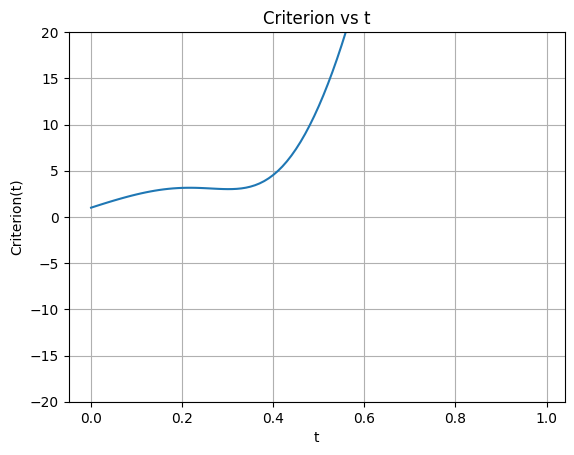

In [9]:
ANNEAL_WEIGHT = 1.0
BUMP_VALUE = 20.0
RUN_METRIC_EVAL = True
names = ["default_linear", "custom_poly", "default_linear"]
print(names)
gamma_list = [
    lambda t : torch.tensor(1) * ANNEAL_WEIGHT+ (BUMP_VALUE * t * (1 - t)),
    lambda t : torch.tensor(-1) * ANNEAL_WEIGHT ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t)+ (BUMP_VALUE * (1 - 2*t)),
    lambda t: torch.zeros_like(t) ,
    lambda t: torch.zeros_like(t)
]
Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99) = {Criterion(torch.tensor(0.99)).item()}")

t = torch.linspace(0.0, 0.99, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.ylim(-20,20)
plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

['default_linear', 'custom_poly', 'default_linear']
Criterion(0.99) = 18361.263671875
Criterion(0.99) = 19351.265625
Criterion(0.99) = 20341.265625
Criterion(0.99) = 21331.267578125
Criterion(0.99) = 22321.26953125
Criterion(0.99) = 27271.2734375


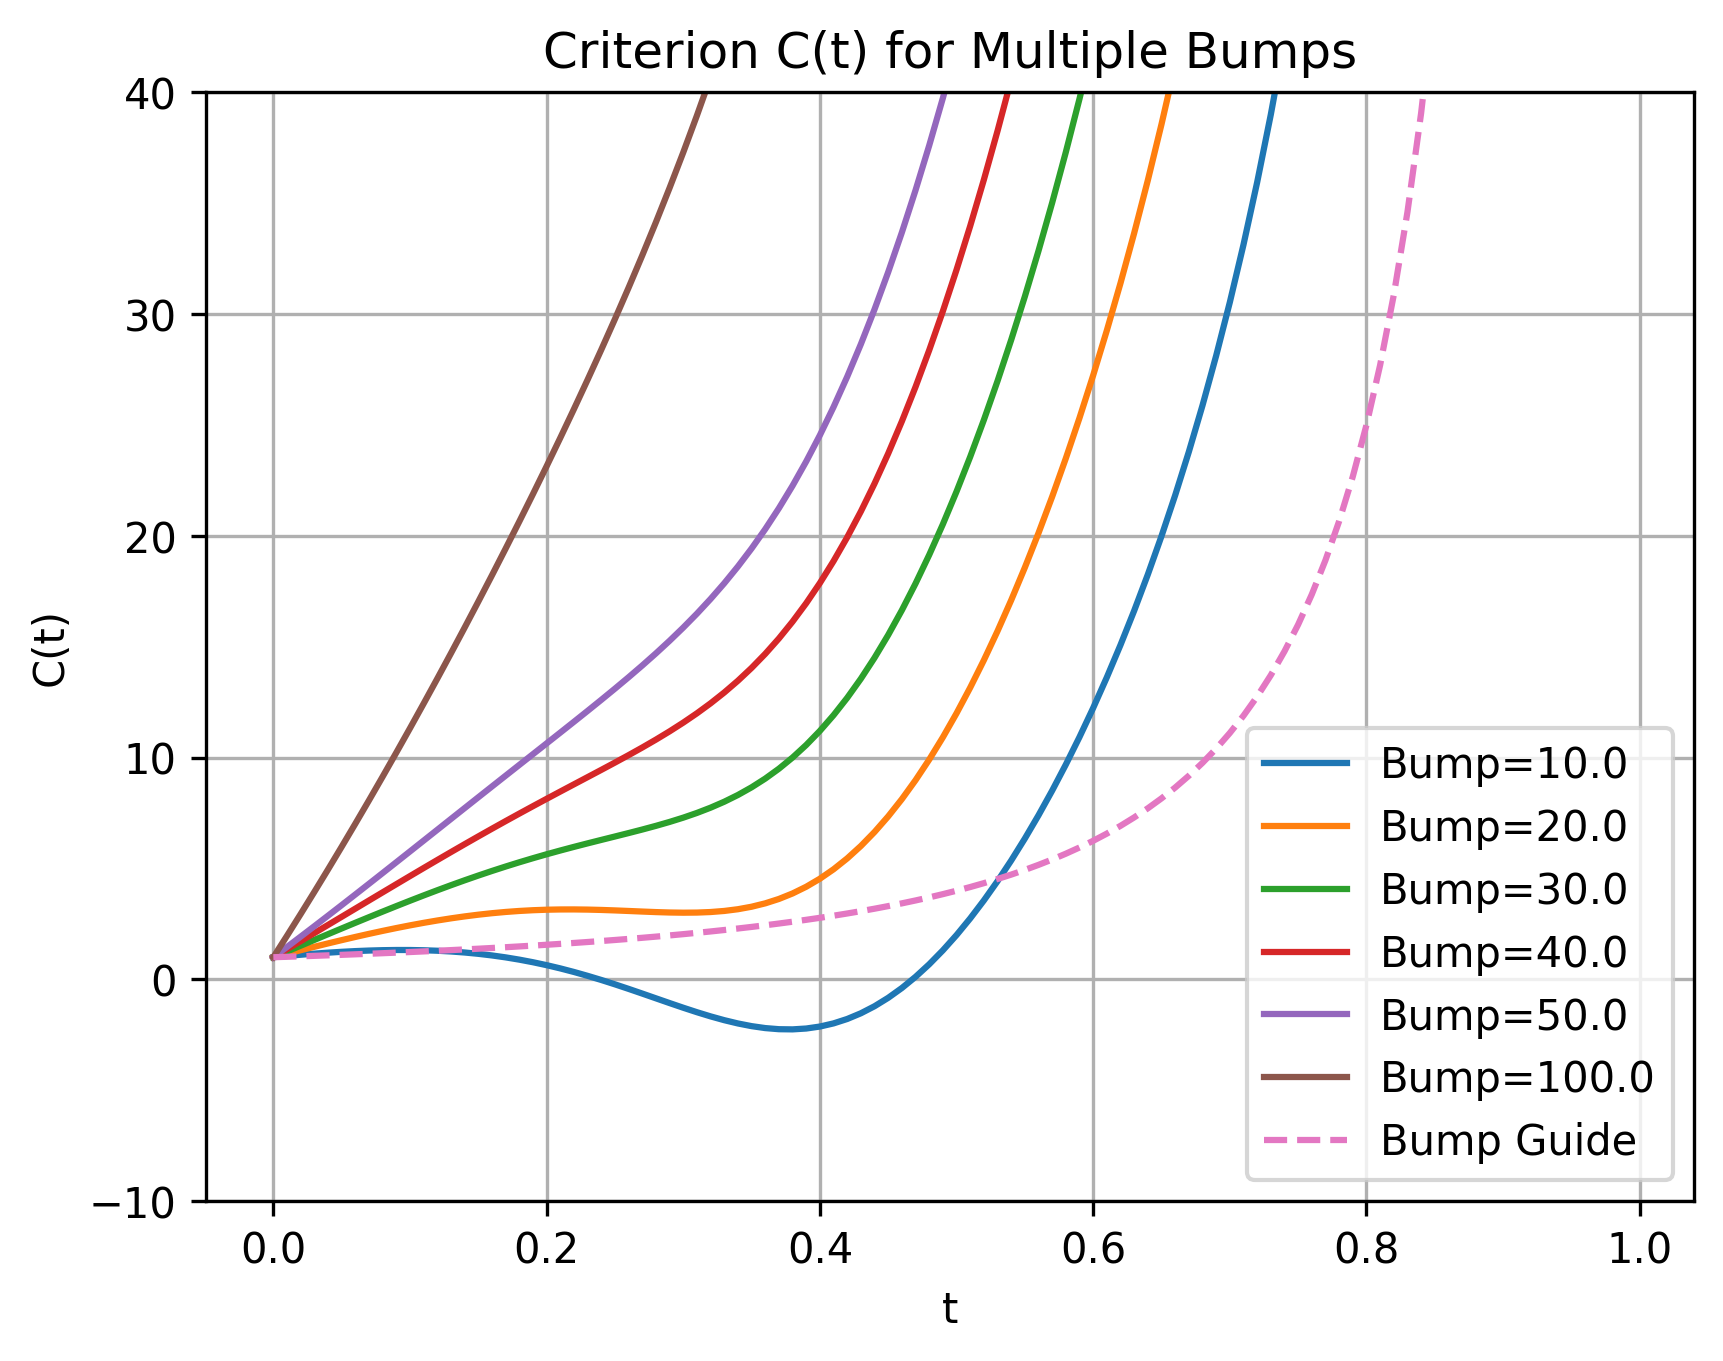

In [24]:
# Multiple Bumps
ANNEAL_WEIGHT = 1.0
BUMP_VALUES = [10.0, 20.0, 30.0, 40.0, 50.0, 100.0]
RUN_METRIC_EVAL = True
names = ["default_linear", "custom_poly", "default_linear"]
print(names)

for BUMP_VALUE in BUMP_VALUES:
    gamma_list = [
        lambda t : torch.tensor(1) * ANNEAL_WEIGHT+ (BUMP_VALUE * t * (1 - t)),
        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT ,
        lambda t : torch.tensor(1)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t)+ (BUMP_VALUE * (1 - 2*t)),
        lambda t: torch.zeros_like(t) ,
        lambda t: torch.zeros_like(t)
    ]
    Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

    print(f"Criterion(0.99) = {Criterion(torch.tensor(0.99)).item()}")

    t = torch.linspace(0.0, 0.99, 100)
    plt.plot(t.numpy(), Criterion(t).numpy(), label=f'Bump={BUMP_VALUE}')

heuristic = lambda t : 1 / (interpolant_schedules[names[0]].alpha_t(t))**2
t = torch.linspace(0.0, 0.99, 100)
plt.plot(t.numpy(), heuristic(t).numpy(), label='Bump Guide', linestyle='--')
plt.xlabel('t')
plt.ylabel('C(t)')
plt.title('Criterion C(t) for Multiple Bumps')
plt.grid(True)
plt.ylim(-10,40)
plt.legend()
plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUES}.png"))
plt.rcParams['figure.dpi'] = 300
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

In [ ]:
RUN_METRIC_EVAL = True
results = []
bs = 10000; n_steps=100

seeds = [0] # seeds=[0,1,2,3,4]
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
    print(f"Seed set to {seed}")

    print("Simulating NR")
    gamma_list = [
        lambda t : torch.tensor(1) * ANNEAL_WEIGHT,
        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
        lambda t : torch.tensor(1)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t)
    ]
    
    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=False
    )
    samples = samples.cpu().numpy()
    if seed == 0:
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_NR")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_NR", deg=-50)
        plt.close(); clear_output()
    
    if RUN_METRIC_EVAL:
        print("Evaluating NR")
        w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
            torch.tensor(samples_gt), torch.tensor(samples)
        )
        results.append([seed, "NR", w1, w2, mmd_rbf, total_var])

    print("Simulating FKC-H (Constant Gammas)")
    gamma_list = [
        lambda t : torch.tensor(1) * ANNEAL_WEIGHT,
        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
        lambda t : torch.tensor(1)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t),
        lambda t: torch.zeros_like(t)
    ]

    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.5, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=True
    )
    samples = samples.cpu().numpy()
    if seed == 0:
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_FKC-H")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_FKC-H", deg=-50)
        plt.close(); clear_output()

    if RUN_METRIC_EVAL:
        print("Evaluating FKC-H")
        w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
            torch.tensor(samples_gt), torch.tensor(samples)
        )
        results.append([seed, "FKC-H", w1, w2, mmd_rbf, total_var])

    print("Simulating ACE (Adaptive Gammas)")
    gamma_list = [
        lambda t : torch.tensor(1) * ANNEAL_WEIGHT+ (BUMP_VALUE * t * (1 - t)),
        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT ,
        lambda t : torch.tensor(1)
    ]
    d_gamma_list = [
        lambda t: torch.zeros_like(t)+ (BUMP_VALUE * (1 - 2*t)),
        lambda t: torch.zeros_like(t) ,
        lambda t: torch.zeros_like(t)
    ]

    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.5, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=True
    )
    samples = samples.cpu().numpy()
    if seed == 0:
        plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_ACE")
        plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}_ACE", deg=-50)
        plt.close(); clear_output()

    if RUN_METRIC_EVAL:
        print("Evaluating ACE")
        w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
            torch.tensor(samples_gt), torch.tensor(samples)
        )
        results.append([seed, "ACE", w1, w2, mmd_rbf, total_var])

df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var."])
df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}.csv", index=False)
print(df)

Evaluating ACE


   seed method        W1        W2   MMD_RBF  Total Var.
0     0     NR  0.778884  1.060071  0.065168    0.593900
1     0  FKC-H  2.016571  2.367048  1.451018    0.913361
2     0    ACE  0.474803  0.606195  0.040838    0.635460


# Experiment 2. Common Schedules

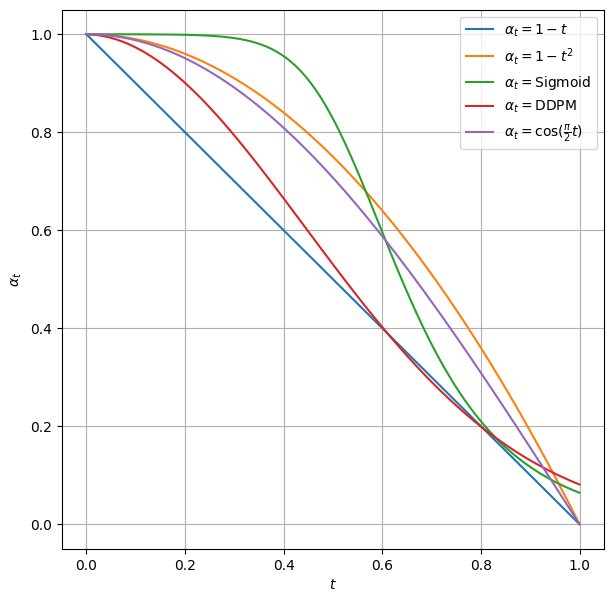

In [6]:
import torch
import itertools
import json
import matplotlib.pyplot as plt
import os

experiment_id = f"{top_experiment_id}/common_schedules"
if os.path.exists(experiment_id) is False:
    os.makedirs(experiment_id)

def load_interpolants_from_json_alpha_only(path):
    with open(path, "r") as f:
        interpolants_raw = json.load(f)

    interpolants = {}
    for name, funcs in interpolants_raw.items():
        alpha_t = eval(funcs["alpha_t"], {"torch": torch})
        interpolants[name] = alpha_t
    return interpolants

# Load
interpolants = load_interpolants_from_json_alpha_only("interpolant_schedules.json")
names = list(interpolants.keys())

t = torch.linspace(0.0, 1.0, 100)

name_eq = {
    "custom_poly": r"$\alpha_t = -4t^3+7t^2-4t+1$",
    "ddpm_linear": r"$\alpha_t = \text{DDPM}$",
    "1-t**2": r"$\alpha_t = 1-t^2$",
    "sigmoid": r"$\alpha_t = \text{Sigmoid}$",
    "default_linear": r"$\alpha_t = 1-t$",
    "cos_t": r"$\alpha_t=\cos(\frac{\pi}{2}t)$"
}


plt.figure(figsize=(7, 7)) 
for name in interpolants.keys():
    plt.plot(t.numpy(), interpolants[name](t).numpy(), label=name_eq[name])
    # print(name, interpolant_schedules[name].alpha_t(0), interpolant_schedules[name].beta_t(0), interpolant_schedules[name].d_alpha_t(0), interpolant_schedules[name].d_beta_t(0))
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha_t$')
# plt.title(r'$\alpha_t$ vs $t$ Graph for Common Noise Schedules')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "alpha_t_plot_common_schedules.png"))
plt.show()

In [24]:
def check_condition(alpha_funcs, n_grid=200, Bump = 0.0, Anneal_weight=1.0):
    """Check sign conditions for [a1, a2, a3]. a1 a3 / a2 and anneal weight applies to (a1 / a2)^w a3"""
    ts = torch.linspace(0.0, 0.99, n_grid)

    if n_grid > 1:
        dt = ts[1] - ts[0]
    else:
        dt = torch.tensor(0.0) 

    alphas = [f(ts) for f in alpha_funcs]
    Bumps = torch.tensor([Bump * t * (1-t) for t in ts])
    if len(alpha_funcs) == 3:
        C = (Anneal_weight + Bumps) / (alphas[0]**2 + 1e-12) - Anneal_weight / (alphas[1]**2 + 1e-12) + 1 / (alphas[2]**2 + 1e-12)
    else:
        raise ValueError("Only supports 3 schedules")

    total_negative_length = 0.0
    if n_grid > 1:
        negative_intervals = C[:-1] < 0
        total_negative_length_tensor = torch.sum(negative_intervals.float()) * dt
        total_negative_length = total_negative_length_tensor.item()

    return (C.min() < 0), ts, C, total_negative_length

name_eq_plot = {
    "ddpm_linear": r"$\text{DDPM}$",
    "1-t**2": r"$1-t^2$",
    "sigmoid": r"$\text{Sigmoid}$",
    "default_linear": r"$1-t$",
    "cos_t": r"$\cos(\frac{\pi}{2}t)$"
}


def find_valid_combinations(interpolants, Anneal_weight=1.0, Bump=0.0):
    collapse_combinations = []

    for a1, a2, a3 in itertools.product(interpolants, repeat=3):
        valid, t, C, total_negative_length = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], Anneal_weight=Anneal_weight, Bump=Bump)
        if valid:
            collapse_combinations.append([a1, a2, a3, total_negative_length])
    collapse_combinations.sort(key=lambda x: x[3], reverse=True)
    unique_combinations = []
    seen = set()
    for combo in collapse_combinations:
        identifier = combo[3]
        if identifier not in seen:
            unique_combinations.append(combo)
            seen.add(identifier)
    collapse_combinations = unique_combinations # Remove duplicates if total_negative_length is the same
    return collapse_combinations

collapse_combinations = find_valid_combinations(interpolants, Anneal_weight=1.0, Bump=0.0)
print(f"There are {len(collapse_combinations)} unique combinations that have path collapse:")
for t in collapse_combinations:
    print(t)

There are 24 unique combinations that have path collapse:
[['1-t**2', 'default_linear', '1-t**2', 0.5721105337142944], ['1-t**2', 'default_linear', 'cos_t', 0.5372864007949829], ['cos_t', 'default_linear', 'cos_t', 0.487537682056427], ['1-t**2', 'default_linear', 'sigmoid', 0.4328140616416931], ['1-t**2', 'ddpm_linear', '1-t**2', 0.4079396724700928], ['sigmoid', 'default_linear', 'sigmoid', 0.3880401849746704], ['sigmoid', 'default_linear', 'cos_t', 0.36316582560539246], ['1-t**2', 'ddpm_linear', 'cos_t', 0.3532160818576813], ['cos_t', 'ddpm_linear', 'cos_t', 0.2935175895690918], ['1-t**2', 'ddpm_linear', 'sigmoid', 0.27859294414520264], ['sigmoid', 'ddpm_linear', 'sigmoid', 0.2487437129020691], ['1-t**2', 'sigmoid', '1-t**2', 0.21889446675777435], ['sigmoid', 'ddpm_linear', 'cos_t', 0.1989949643611908], ['1-t**2', 'sigmoid', 'cos_t', 0.17412059009075165], ['cos_t', 'sigmoid', 'cos_t', 0.11442210525274277], ['1-t**2', 'default_linear', 'ddpm_linear', 0.10944723337888718], ['ddpm_linear

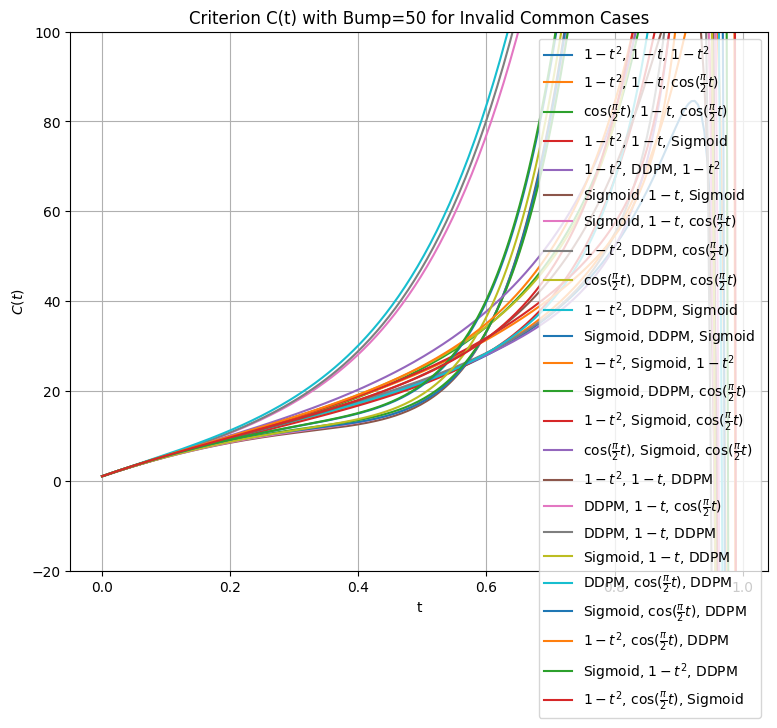

In [29]:
Bump = 50
plt.figure(figsize=(9,7))
plt.title(f'Criterion C(t) with Bump={Bump} for Invalid Common Cases')
for names in collapse_combinations:
    a1, a2, a3, invalid_interval = names
    valid, t, C, invalid_interval = check_condition([interpolants[a1], interpolants[a2], interpolants[a3]], Anneal_weight=1.0, Bump=Bump)
    plt.ylim((-20,100))
    plt.grid(True)
    plt.plot(t.numpy(), C.numpy(), label=f'{name_eq_plot[a1]}, {name_eq_plot[a2]}, {name_eq_plot[a3]}')
    plt.legend()
plt.xlabel('t')
plt.ylabel(r"$C(t)$")
plt.savefig(os.path.join(experiment_id, f"Criterion_plot_a1a2a3_bump={Bump}.png"))
plt.show()
plt.close()

Conditioning on A=0, B=0


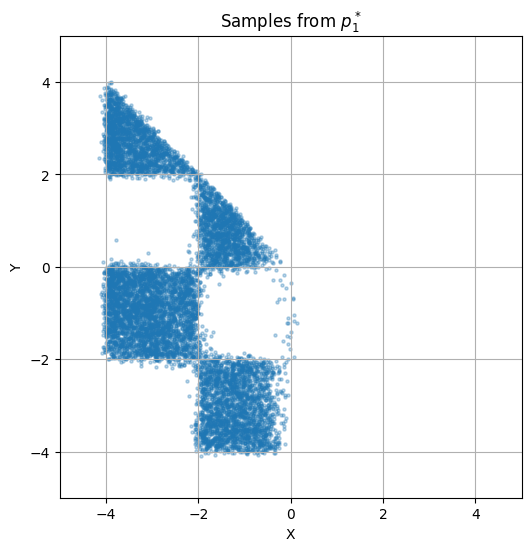

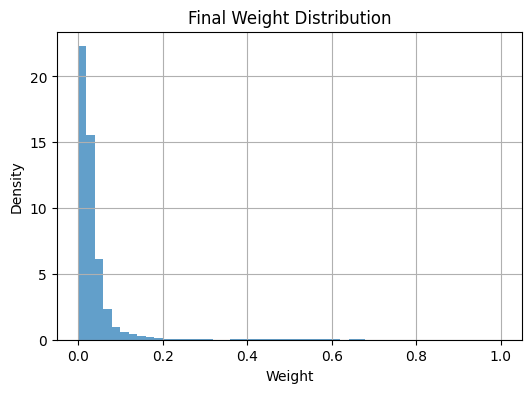

KeyboardInterrupt: 

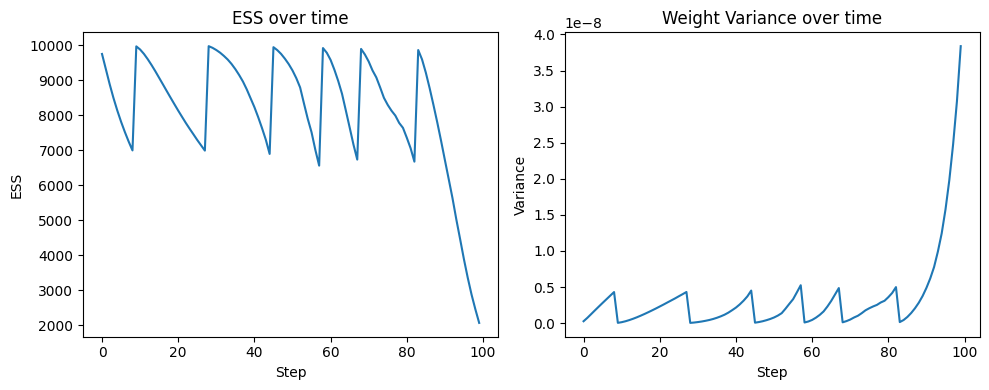

In [34]:
for names in collapse_combinations:
    bs = 10000; n_steps=1000
    seeds = [0,1,2,3,4]
    ESS_THRESHOLD = 0.7
    ANNEAL_WEIGHT = 1.0
    BUMP_VALUE = 30.0
    RUN_METRIC_EVAL = True

    subexperiment_id = f"{names}"
    experiment_id = f"{top_experiment_id}/[{names[3]:.4f}]{subexperiment_id}_Realistic_Synthetic_Schedule_for_MPC"
    if not os.path.exists(experiment_id):
        os.makedirs(experiment_id)

    u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
    s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
    u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
    s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
    u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
    s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

    def v1_fn(x, t, A): return u_model1(x, t, A)
    def s1_fn(x, t, A): return s_model1(x, t, A)
    def v2_fn(x, t): return u_model3(x, t)
    def s2_fn(x, t): return s_model3(x, t)
    def v3_fn(z, t, B): return u_model2(z, t, B)
    def s3_fn(z, t, B): return s_model2(z, t, B)
    def sigma_fn(t): return 0.5 * torch.ones_like(t)

    v_fn_list=[
            lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
            lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
            lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
        ]
    s_fn_list=[
            lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
            lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
            lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
        ]
    proj_list=[
            lambda z: z[:, :1],    # project to X 
            lambda z: z[:, :1],    # project to X
            lambda z: z            # identity for Z
        ]
    emb_list=[
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
            lambda z: z  # identity
        ]
    print(f"{names} models loaded.")


    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f"Seed set to {seed}")

        for Method_name in ["FKC", "ACE"]:
            print(f"Method: {Method_name}")
            if Method_name == "FKC":
                    print("Simulating FKC (Constant Gammas)")
                    gamma_list = [
                        lambda t : torch.tensor(1) * ANNEAL_WEIGHT,
                        lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
                        lambda t : torch.tensor(1)
                    ]
                    d_gamma_list = [
                        lambda t: torch.zeros_like(t),
                        lambda t: torch.zeros_like(t),
                        lambda t: torch.zeros_like(t)
                    ]
            elif Method_name == "ACE":
                print("Simulating ACE (Adaptive Gammas)")
                gamma_list = [
                    lambda t : torch.tensor(1) * ANNEAL_WEIGHT + (BUMP_VALUE * t * (1 - t)),
                    lambda t : torch.tensor(-1) * ANNEAL_WEIGHT,
                    lambda t : torch.tensor(1)
                ]
                d_gamma_list = [
                    lambda t: torch.zeros_like(t) + (BUMP_VALUE * (1 - 2*t)),
                    lambda t: torch.zeros_like(t),
                    lambda t: torch.zeros_like(t)
                ]
            for A, B in [(1,1), (1,0), (0,1), (0,0)]:
                print(f"Conditioning on A={A}, B={B}")

                x0 = torch.randn(bs, 2).to("cuda")
                samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
                    x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
                    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
                    t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=ESS_THRESHOLD, print_resample_history=True,
                    gamma_list=gamma_list,
                    d_gamma_list=d_gamma_list,
                    resample=True
                )
                samples = samples.cpu().numpy()
                plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_{Method_name}_seed{seed}_AB={A}{B}_Bump={BUMP_VALUE}")
                plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_{Method_name}_seed{seed}_AB={A}{B}_Bump={BUMP_VALUE}", deg=-50)
                plt.close(); clear_output()

                if RUN_METRIC_EVAL:
                    print(f"Evaluating {Method_name} for AB={A}{B}")
                    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
                    w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
                        torch.tensor(samples_gt), torch.tensor(samples)
                    )
                    results.append([seed, Method_name, w1, w2, mmd_rbf, total_var, A, B])

                    df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var.", "A", "B"])
                    df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_ESS{ESS_THRESHOLD}_{names}_ANNEAL={ANNEAL_WEIGHT}_BUMP={BUMP_VALUE}.csv", index=False)

In [118]:
# names = ["cos_t", "sigmoid", "1-t**2"]
# names = ["1-t**2", "sigmoid", "cos_t"] # (0.7316, 0.9025)
# names = ["1-t**2", "sigmoid", "1-t**2"] # (0.703, 0.921)
names = ["default_linear", "custom_poly", "default_linear"] #-> Bump = 14 works
names = ["sigmoid", "ddpm_linear", "sigmoid"] # -> Bump = 5 works
# names = ["1-t**2", "default_linear", "1-t**2"]

print(names)
subexperiment_id = f"{names}"
experiment_id = f"{top_experiment_id}/{subexperiment_id}_Common_Schedules_with_Collapse"
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

Bump = 0
gamma_list = [
    lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

# t = torch.linspace(0.01, 0.95, 100)
# plt.plot(t.numpy(), Criterion(t).numpy())
# plt.xlabel('t')
# plt.ylabel('Criterion(t)')
# plt.title('Criterion vs t')
# plt.grid(True)
# plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_Bump{Bump}.png"))
# plt.show()

# # print when Criterion = 0
# for i in range(len(t)-1):
#     if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
#         print("Criterion(t): pos -> neg at t =", t[i].item())
#         break
# for i in range(len(t)-1):
#     if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
#         print("Criterion(t) neg -> pos at t =", t[i].item())
#         break


u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{model_path}/u_model1_X_given_A_alpha={names[0]}.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{model_path}/s_model1_X_given_A_alpha={names[0]}.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{model_path}/u_model2_XY_given_B_alpha={names[2]}.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{model_path}/s_model2_XY_given_B_alpha={names[2]}.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{model_path}/u_model3_X_alpha={names[1]}.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{model_path}/s_model3_X_alpha={names[1]}.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
def sigma_fn(t): return 0.5 * torch.ones_like(t)

v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ]
s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ]
proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ]
emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ]

print("Models loaded.")

# bs = 10000; n_steps=1000
bs = 5000; n_steps=100
seeds = [0, 2, 3 ,4, 5]
results = []
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f"Seed set to {seed}")

    x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
    A, B = 1, 1  # Conditioning values
    samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
        x0=x0, v_fn_list=v_fn_list, s_fn_list=s_fn_list, proj_list=proj_list, emb_list=emb_list, sigma_fn=sigma_fn,
        v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
        t0=0.0, t1=1.0, n_steps=n_steps, device="cuda", ess_threshold=0.7, print_resample_history=True,
        gamma_list=gamma_list,
        d_gamma_list=d_gamma_list,
        resample=True, t_max = 1.0 #if n_steps < 1000 else 0.85
    )
    samples = samples.cpu().numpy()
    # plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/alpha={names}_FKC-H_seed{seed}")
    # plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name=f"alpha={names}_FKC-H_seed{seed}", deg=-50)
    print("Evaluating...")
    samples_gt = ground_truth_hcg(bs, cond_A=A, cond_B=B).numpy()
    w1, w2, mmd_rbf, total_var = compute_sample_based_metrics(
        torch.tensor(samples_gt), torch.tensor(samples)
    )
    print(w1, w2, mmd_rbf, total_var)
    results.append([seed, f"ACE_Bump{Bump}", w1, w2, mmd_rbf, total_var])
df = pd.DataFrame(results, columns=["seed", "method", "W1", "W2", "MMD_RBF", "Total Var."])
df.to_csv(f"{experiment_id}/experiment_results_numseeds{len(seeds)}_bs{bs}_n_steps{n_steps}_Bump{Bump}.csv", index=False)
print(df)

['sigmoid', 'ddpm_linear', 'sigmoid']
Criterion(0.99999) = 333.5006103515625
Models loaded.
Seed set to 0


/tmp/ipykernel_2965783/3322431032.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
/tmp/ipykernel_2965783/3322431032.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),


Evaluating...
0.20016452570009133 0.26039064779437626 0.01162046194076538 0.7526
Seed set to 2
Evaluating...
0.22509925428068484 0.37608466361633497 0.010809004306793213 0.7567929585917184
Seed set to 3
Evaluating...
0.1225703850173756 0.18104026479377963 0.0074225664138793945 0.7502
Seed set to 4
Evaluating...
0.1382031651382303 0.19307595170213218 0.007743775844573975 0.7542000000000001
Seed set to 5
Evaluating...
0.150939461770132 0.20740443444210221 0.008749306201934814 0.747592598519704
   seed     method        W1        W2   MMD_RBF  Total Var.
0     0  ACE_Bump0  0.200165  0.260391  0.011620    0.752600
1     2  ACE_Bump0  0.225099  0.376085  0.010809    0.756793
2     3  ACE_Bump0  0.122570  0.181040  0.007423    0.750200
3     4  ACE_Bump0  0.138203  0.193076  0.007744    0.754200
4     5  ACE_Bump0  0.150939  0.207404  0.008749    0.747593


['default_linear', 'custom_poly', 'default_linear']
Criterion(0.99999) = 17452441600.0
Criterion(0.99999) = 17455435776.0


/tmp/ipykernel_1074734/2857177842.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
/tmp/ipykernel_1074734/2857177842.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),


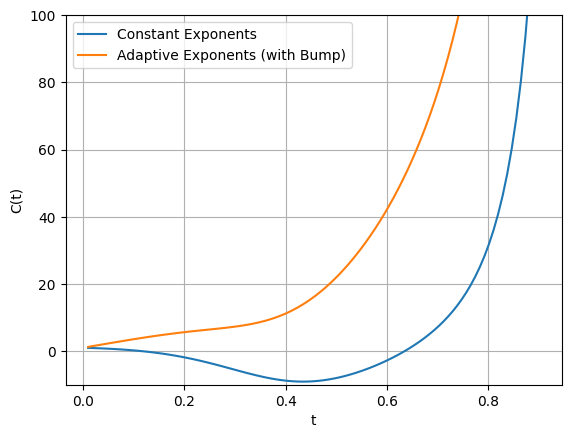

In [8]:
import torch
import matplotlib.pyplot as plt


# names = ["cos_t", "sigmoid", "1-t**2"]
# names = ["1-t**2", "sigmoid", "cos_t"] # (0.7316, 0.9025)
# names = ["1-t**2", "sigmoid", "1-t**2"] # (0.703, 0.921)
names = ["default_linear", "custom_poly", "default_linear"] #-> Bump = 14 works
# names = ["sigmoid", "ddpm_linear", "sigmoid"] # -> Bump = 5 works
# names = ["1-t**2", "default_linear", "1-t**2"]

print(names)
experiment_id = "."

Bump = 0
gamma_list = [
    lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy(), label="Constant Exponents")
plt.xlabel('t')
plt.ylabel('C(t)')
# plt.title('Evolution of Criterion C(t) over time')
plt.grid(True)


Bump = 30
gamma_list = [
    lambda t : torch.tensor(1) + torch.tensor(Bump * t*(1-t)),
    lambda t : torch.tensor(1) * torch.tensor(-1) ,
    lambda t : torch.tensor(1)
]
d_gamma_list = [
    lambda t: torch.zeros_like(t) + torch.tensor(Bump * (1 - 2*t)),
    lambda t: torch.zeros_like(t),
    lambda t: torch.zeros_like(t)
]

Criterion = lambda t: sum([ gamma_list[i](t) / (interpolant_schedules[names[i]].alpha_t(t))**2 for i in range(len(names)) ])

print(f"Criterion(0.99999) = {Criterion(torch.tensor(0.99999)).item()}")

t = torch.linspace(0.01, 0.9, 100)
plt.plot(t.numpy(), Criterion(t).numpy(), label='Adaptive Exponents (with Bump)')
# plt.plot(label=r'C(t)>0 $\Rightarrow$ Marginal Path Existence')
# plt.plot(label=r'C(t)<0 $\Rightarrow$ Marginal Path Collapse')
plt.legend()
plt.ylim((-10,100))
plt.savefig(os.path.join(experiment_id, f"Criterion_plot_{names}_Bump{Bump}.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion(t): pos -> neg at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion(t) neg -> pos at t =", t[i].item())
        break